# LAB 2

## Name - Aditya Arya
## Roll - 23cs3068

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import random
import time
import copy
import math

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [51]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [52]:
X = np.array([
    [1, 2, 0, 1, 3],
    [3, 1, 2, 2, 0],
    [0, 2, 3, 1, 1],
    [1, 0, 2, 3, 2],
    [2, 1, 0, 2, 1]
])

K = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

print("Input:")
print(X)

print("\nKernel:")
print(K)

Input:
[[1 2 0 1 3]
 [3 1 2 2 0]
 [0 2 3 1 1]
 [1 0 2 3 2]
 [2 1 0 2 1]]

Kernel:
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]


In [53]:
def cross_correlation(input_matrix, kernel, padding=0, stride=1):
    padded = np.pad(
        input_matrix,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    H, W = padded.shape
    KH, KW = kernel.shape

    out_h = (H - KH) // stride + 1
    out_w = (W - KW) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = padded[
                i*stride:i*stride+KH,
                j*stride:j*stride+KW
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [54]:
output_no_padding = cross_correlation(
    X,
    K,
    padding=0,
    stride=1
)

print("Output with stride=1 and padding=0:")
print(output_no_padding)

Output with stride=1 and padding=0:
[[ 0.  0.  3.]
 [-6. -2.  6.]
 [-3. -6.  1.]]


In [55]:
output_padding = cross_correlation(
    X,
    K,
    padding=1,
    stride=1
)

print("Output with stride=1 and padding=1:")
print(output_padding)

Output with stride=1 and padding=1:
[[-5.  3.  1. -4.  4.]
 [-6.  0.  0.  3.  6.]
 [-5. -6. -2.  6.  7.]
 [-3. -3. -6.  1.  9.]
 [-2.  3. -5. -2.  7.]]


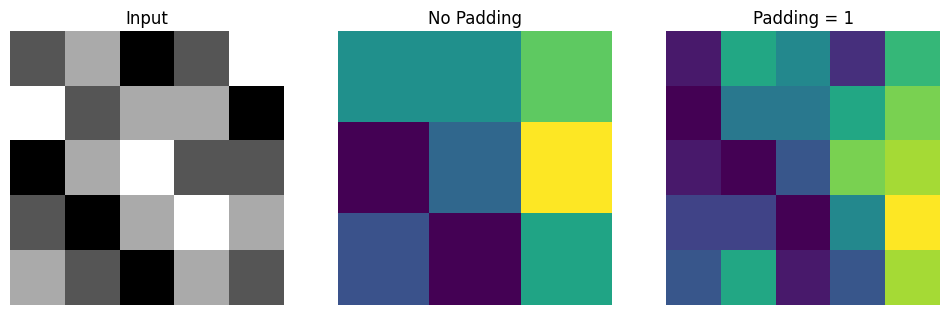

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(X, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(output_no_padding, cmap='viridis')
axes[1].set_title("No Padding")
axes[1].axis("off")

axes[2].imshow(output_padding, cmap='viridis')
axes[2].set_title("Padding = 1")
axes[2].axis("off")

plt.show()

In [57]:
def output_size(H, K, P, S):
    return math.floor((H + 2*P - K) / S) + 1

H = 128
W = 128

# Conv 1
H1 = output_size(H, 5, 2, 2)
W1 = output_size(W, 5, 2, 2)

# Pool 1
H2 = output_size(H1, 2, 0, 2)
W2 = output_size(W1, 2, 0, 2)

# Conv 2
H3 = output_size(H2, 3, 1, 1)
W3 = output_size(W2, 3, 1, 1)

# Pool 2
H4 = output_size(H3, 2, 0, 2)
W4 = output_size(W3, 2, 0, 2)

print("Input:       ", (128, 128, 3))
print("Conv1:       ", (H1, W1, 32))
print("ReLU:        ", (H1, W1, 32))
print("MaxPool1:    ", (H2, W2, 32))
print("Conv2:       ", (H3, W3, 64))
print("ReLU:        ", (H3, W3, 64))
print("MaxPool2:    ", (H4, W4, 64))

Input:        (128, 128, 3)
Conv1:        (64, 64, 32)
ReLU:         (64, 64, 32)
MaxPool1:     (32, 32, 32)
Conv2:        (32, 32, 64)
ReLU:         (32, 32, 64)
MaxPool2:     (16, 16, 64)


In [58]:
example = torch.randn(1, 3, 128, 128)

layer1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=5,
    stride=2,
    padding=2
)

pool1 = nn.MaxPool2d(2, 2)

layer2 = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1
)

pool2 = nn.MaxPool2d(2, 2)

x = layer1(example)
print("After Conv1:", x.shape)

x = torch.relu(x)
print("After ReLU:", x.shape)

x = pool1(x)
print("After Pool1:", x.shape)

x = layer2(x)
print("After Conv2:", x.shape)

x = torch.relu(x)
print("After ReLU:", x.shape)

x = pool2(x)
print("After Pool2:", x.shape)

After Conv1: torch.Size([1, 32, 64, 64])
After ReLU: torch.Size([1, 32, 64, 64])
After Pool1: torch.Size([1, 32, 32, 32])
After Conv2: torch.Size([1, 64, 32, 32])
After ReLU: torch.Size([1, 64, 32, 32])
After Pool2: torch.Size([1, 64, 16, 16])


In [59]:
example = torch.randn(1, 3, 128, 128)

layer1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=5,
    stride=2,
    padding=2
)

pool1 = nn.MaxPool2d(2, 2)

layer2 = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3,
    stride=1,
    padding=1
)

pool2 = nn.MaxPool2d(2, 2)

x = layer1(example)
print("After Conv1:", x.shape)

x = torch.relu(x)
print("After ReLU:", x.shape)

x = pool1(x)
print("After Pool1:", x.shape)

x = layer2(x)
print("After Conv2:", x.shape)

x = torch.relu(x)
print("After ReLU:", x.shape)

x = pool2(x)
print("After Pool2:", x.shape)

After Conv1: torch.Size([1, 32, 64, 64])
After ReLU: torch.Size([1, 32, 64, 64])
After Pool1: torch.Size([1, 32, 32, 32])
After Conv2: torch.Size([1, 64, 32, 32])
After ReLU: torch.Size([1, 64, 32, 32])
After Pool2: torch.Size([1, 64, 16, 16])


In [60]:
out_channels = 64
in_channels = 32
kernel_size = 3

conv_weights = out_channels * in_channels * kernel_size * kernel_size
conv_bias = out_channels

conv_parameters = conv_weights + conv_bias

print("Weights:", conv_weights)
print("Bias:", conv_bias)
print("Total parameters:", conv_parameters)

Weights: 18432
Bias: 64
Total parameters: 18496


In [61]:
H = 32
W = 32
C = 32
neurons = 64

fc_parameters = H * W * C * neurons + neurons

ratio = fc_parameters / conv_parameters

print("Fully connected parameters:", fc_parameters)
print("CNN parameters:", conv_parameters)
print("FC/CNN ratio:", ratio)

Fully connected parameters: 2097216
CNN parameters: 18496
FC/CNN ratio: 113.38754325259515


In [62]:
layers = [
    ("Conv1", 3, 1),
    ("Conv2", 3, 1),
    ("Pool1", 2, 2),
    ("Conv3", 3, 1),
    ("Pool2", 2, 2)
]

r = 1
j = 1

print(f"{'Layer':<10}{'Kernel':<10}{'Stride':<10}{'RF':<10}{'Jump':<10}")

for name, k, s in layers:
    r = r + (k - 1) * j
    j = j * s

    print(f"{name:<10}{k:<10}{s:<10}{r:<10}{j:<10}")

Layer     Kernel    Stride    RF        Jump      
Conv1     3         1         3         1         
Conv2     3         1         5         1         
Pool1     2         2         6         2         
Conv3     3         1         10        2         
Pool2     2         2         12        4         


In [63]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 50000
Validation samples: 10000
Test samples: 10000


In [64]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


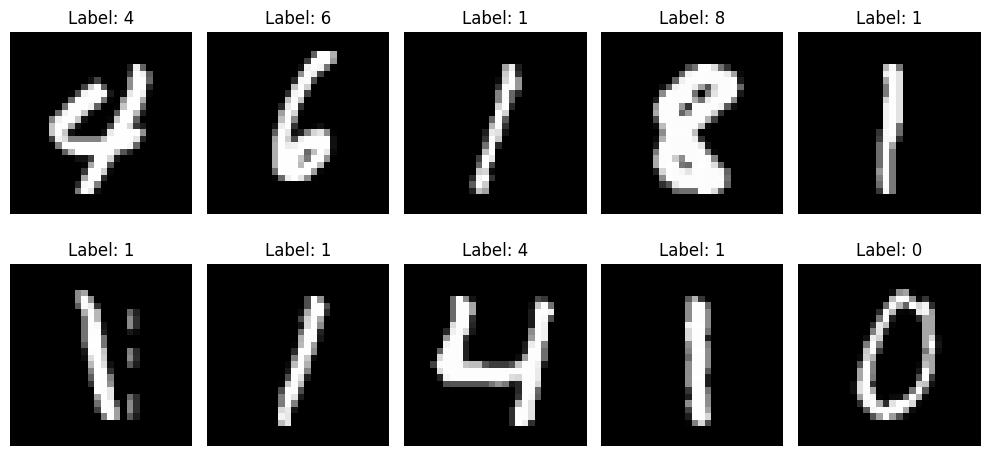

In [65]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [66]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x


model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [67]:
x = torch.randn(1, 1, 28, 28).to(device)

print("Input:", x.shape)

x = model.conv1(x)
print("Conv1:", x.shape)

x = model.relu1(x)
print("ReLU1:", x.shape)

x = model.pool1(x)
print("Pool1:", x.shape)

x = model.conv2(x)
print("Conv2:", x.shape)

x = model.relu2(x)
print("ReLU2:", x.shape)

x = model.pool2(x)
print("Pool2:", x.shape)

x = model.flatten(x)
print("Flatten:", x.shape)

x = model.fc1(x)
print("Linear 128:", x.shape)

x = model.relu3(x)
print("ReLU:", x.shape)

x = model.fc2(x)
print("Output:", x.shape)

Input: torch.Size([1, 1, 28, 28])
Conv1: torch.Size([1, 32, 28, 28])
ReLU1: torch.Size([1, 32, 28, 28])
Pool1: torch.Size([1, 32, 14, 14])
Conv2: torch.Size([1, 64, 14, 14])
ReLU2: torch.Size([1, 64, 14, 14])
Pool2: torch.Size([1, 64, 7, 7])
Flatten: torch.Size([1, 3136])
Linear 128: torch.Size([1, 128])
ReLU: torch.Size([1, 128])
Output: torch.Size([1, 10])


In [68]:
def parameter_table(model):
    total = 0

    for name, param in model.named_parameters():
        count = param.numel()

        print(
            f"{name:<25} "
            f"{str(list(param.shape)):<20} "
            f"{count}"
        )

        total += count

    print("-" * 60)
    print("Total trainable parameters:", total)


parameter_table(model)

conv1.weight              [32, 1, 3, 3]        288
conv1.bias                [32]                 32
conv2.weight              [64, 32, 3, 3]       18432
conv2.bias                [64]                 64
fc1.weight                [128, 3136]          401408
fc1.bias                  [128]                128
fc2.weight                [10, 128]            1280
fc2.bias                  [10]                 10
------------------------------------------------------------
Total trainable parameters: 421642


In [69]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [21]:
LEARNING_RATE = 0.001
EPOCHS = 10

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1/10 | Train Loss: 0.1857 | Val Loss: 0.0876 | Train Acc: 0.9428 | Val Acc: 0.9722
Epoch 2/10 | Train Loss: 0.0508 | Val Loss: 0.0547 | Train Acc: 0.9840 | Val Acc: 0.9838
Epoch 3/10 | Train Loss: 0.0345 | Val Loss: 0.0492 | Train Acc: 0.9890 | Val Acc: 0.9858
Epoch 4/10 | Train Loss: 0.0263 | Val Loss: 0.0699 | Train Acc: 0.9916 | Val Acc: 0.9790
Epoch 5/10 | Train Loss: 0.0180 | Val Loss: 0.0401 | Train Acc: 0.9944 | Val Acc: 0.9878
Epoch 6/10 | Train Loss: 0.0152 | Val Loss: 0.0425 | Train Acc: 0.9951 | Val Acc: 0.9886
Epoch 7/10 | Train Loss: 0.0128 | Val Loss: 0.0478 | Train Acc: 0.9957 | Val Acc: 0.9875
Epoch 8/10 | Train Loss: 0.0098 | Val Loss: 0.0451 | Train Acc: 0.9965 | Val Acc: 0.9902
Epoch 9/10 | Train Loss: 0.0087 | Val Loss: 0.0468 | Train Acc: 0.9971 | Val Acc: 0.9893
Epoch 10/10 | Train Loss: 0.0070 | Val Loss: 0.0458 | Train Acc: 0.9976 | Val Acc: 0.9895

Training time: 884.74 seconds


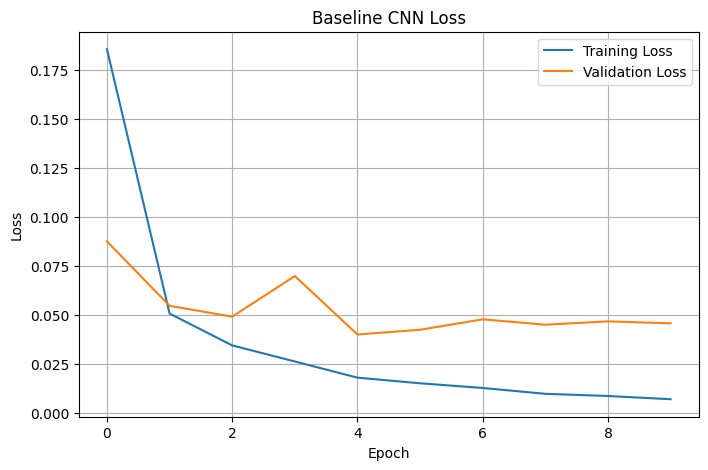

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.grid(True)

plt.show()

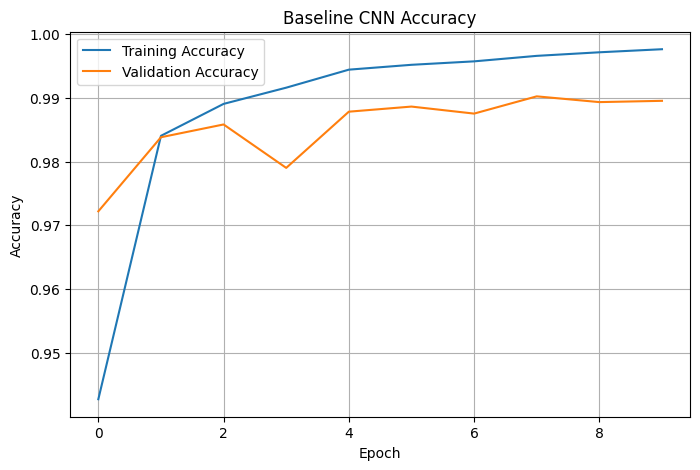

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.032480515607958296
Test Accuracy: 0.9911
Test Accuracy (%): 99.11


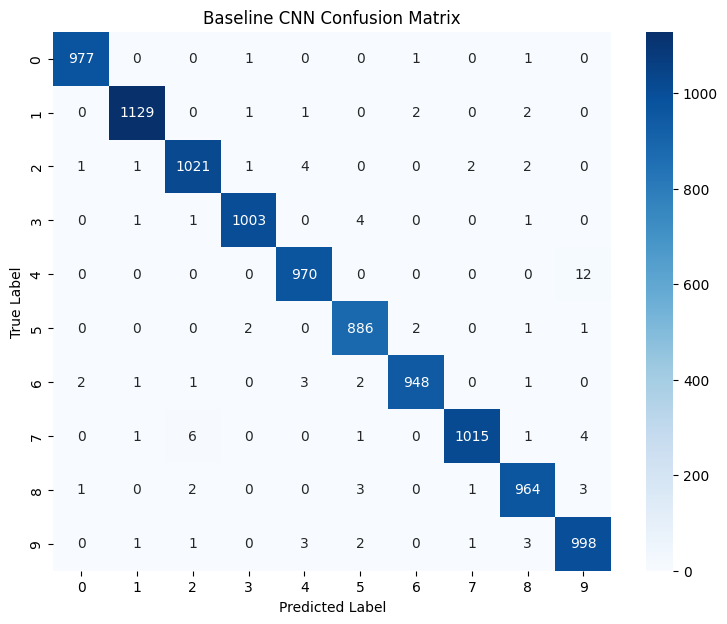

In [25]:
def get_predictions(model, loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return np.array(all_labels), np.array(all_predictions)


y_true, y_pred = get_predictions(
    model,
    test_loader
)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")

plt.show()

In [26]:
class VariantA(BaselineCNN):
    pass

In [27]:
class VariantB(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.relu1(self.conv1(x))

        x = self.relu2(self.conv2(x))

        x = self.flatten(x)

        x = self.relu3(self.fc1(x))

        x = self.fc2(x)

        return x

In [28]:
class VariantC(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )

        self.gelu1 = nn.GELU()

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )

        self.gelu2 = nn.GELU()

        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.gelu3 = nn.GELU()

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.gelu1(self.conv1(x))
        x = self.pool1(x)

        x = self.gelu2(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.gelu3(self.fc1(x))

        x = self.fc2(x)

        return x

In [29]:
def train_model(model, epochs=10):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start = time.time()

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

    elapsed = time.time() - start

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion
    )

    return model, history, test_acc, elapsed

In [30]:
models = {}
histories = {}
results = {}

for name, model_class in [
    ("A_Baseline", VariantA),
    ("B_Stride2", VariantB),
    ("C_GELU", VariantC)
]:

    print("\n" + "="*60)
    print(name)
    print("="*60)

    trained_model, history, test_acc, elapsed = train_model(
        model_class(),
        epochs=10
    )

    models[name] = trained_model
    histories[name] = history

    parameter_count = sum(
        p.numel()
        for p in trained_model.parameters()
        if p.requires_grad
    )

    results[name] = {
        "parameters": parameter_count,
        "test_accuracy": test_acc,
        "training_time": elapsed
    }

print("\nResults:")
for name, result in results.items():
    print(name, result)


A_Baseline


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss 0.1905 | Val Loss 0.0662 | Val Acc 0.9791
Epoch 2/10 | Train Loss 0.0514 | Val Loss 0.0541 | Val Acc 0.9841
Epoch 3/10 | Train Loss 0.0344 | Val Loss 0.0468 | Val Acc 0.9862
Epoch 4/10 | Train Loss 0.0245 | Val Loss 0.0505 | Val Acc 0.9862
Epoch 5/10 | Train Loss 0.0187 | Val Loss 0.0442 | Val Acc 0.9868
Epoch 6/10 | Train Loss 0.0155 | Val Loss 0.0441 | Val Acc 0.9887
Epoch 7/10 | Train Loss 0.0117 | Val Loss 0.0383 | Val Acc 0.9902
Epoch 8/10 | Train Loss 0.0088 | Val Loss 0.0403 | Val Acc 0.9896
Epoch 9/10 | Train Loss 0.0096 | Val Loss 0.0513 | Val Acc 0.9874
Epoch 10/10 | Train Loss 0.0065 | Val Loss 0.0535 | Val Acc 0.9877

B_Stride2
Epoch 1/10 | Train Loss 0.2428 | Val Loss 0.0961 | Val Acc 0.9698
Epoch 2/10 | Train Loss 0.0684 | Val Loss 0.0730 | Val Acc 0.9787
Epoch 3/10 | Train Loss 0.0429 | Val Loss 0.0535 | Val Acc 0.9843
Epoch 4/10 | Train Loss 0.0307 | Val Loss 0.0562 | Val Acc 0.9826
Epoch 5/10 | Train Loss 0.0222 | Val Loss 0.0497 | Val Acc 0.984

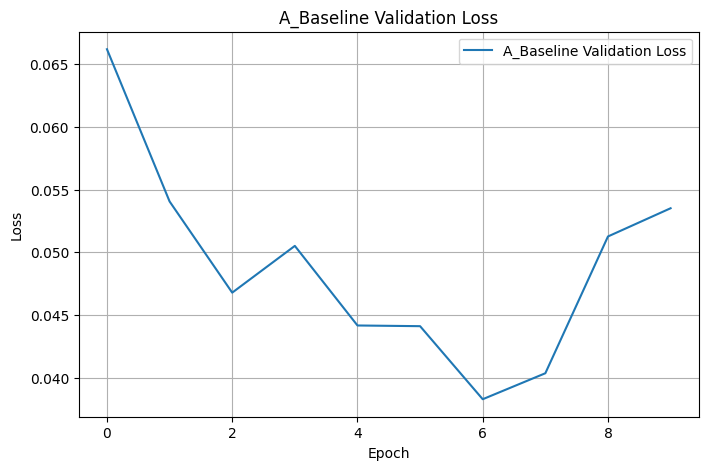

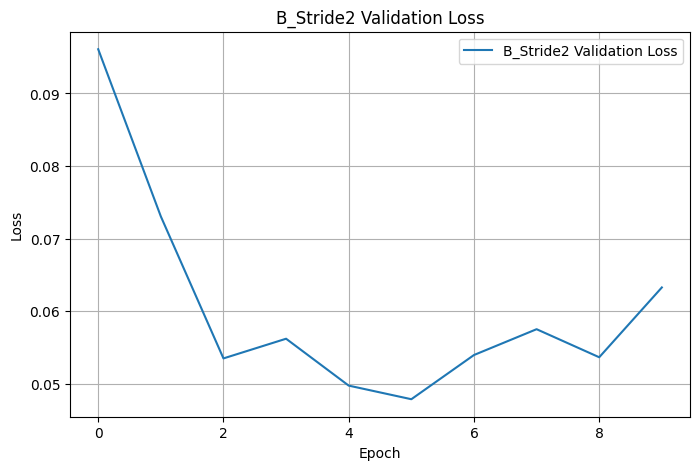

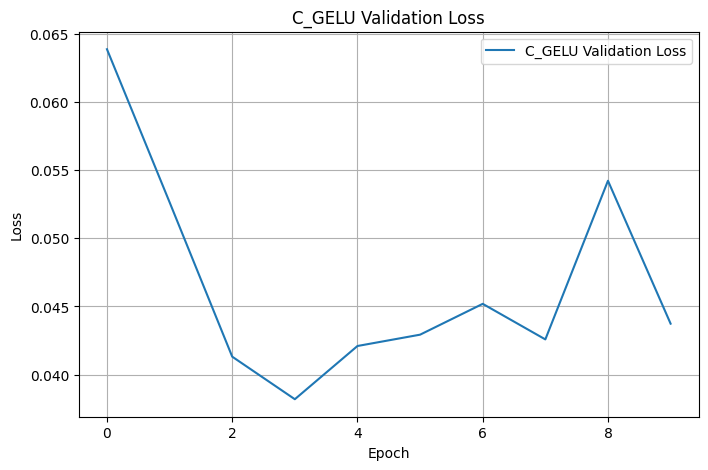

In [31]:
for name, history in histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["val_loss"],
        label=f"{name} Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name} Validation Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

In [32]:
import pandas as pd

ablation_df = pd.DataFrame(results).T

ablation_df

,parameters,test_accuracy,training_time
A_Baseline,421642.0,0.9898,798.326926
B_Stride2,421642.0,0.9867,300.213573
C_GELU,421642.0,0.9903,821.027284


In [33]:
class CNN3x3(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [34]:
class CNN5x5(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 24, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 48, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [35]:
model_3x3 = CNN3x3()
model_5x5 = CNN5x5()

params_3x3 = sum(
    p.numel()
    for p in model_3x3.parameters()
)

params_5x5 = sum(
    p.numel()
    for p in model_5x5.parameters()
)

print("3x3 parameters:", params_3x3)
print("5x5 parameters:", params_5x5)

3x3 parameters: 421642
5x5 parameters: 331946


In [36]:
model_3x3, history_3x3, acc_3x3, time_3x3 = train_model(
    model_3x3,
    epochs=10
)

model_5x5, history_5x5, acc_5x5, time_5x5 = train_model(
    model_5x5,
    epochs=10
)

print("\n3x3 accuracy:", acc_3x3)
print("5x5 accuracy:", acc_5x5)

print("\n3x3 training time:", time_3x3)
print("5x5 training time:", time_5x5)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss 0.1838 | Val Loss 0.0690 | Val Acc 0.9787
Epoch 2/10 | Train Loss 0.0502 | Val Loss 0.0461 | Val Acc 0.9859
Epoch 3/10 | Train Loss 0.0347 | Val Loss 0.0422 | Val Acc 0.9868
Epoch 4/10 | Train Loss 0.0255 | Val Loss 0.0338 | Val Acc 0.9903
Epoch 5/10 | Train Loss 0.0206 | Val Loss 0.0462 | Val Acc 0.9872
Epoch 6/10 | Train Loss 0.0146 | Val Loss 0.0421 | Val Acc 0.9883
Epoch 7/10 | Train Loss 0.0113 | Val Loss 0.0447 | Val Acc 0.9872
Epoch 8/10 | Train Loss 0.0100 | Val Loss 0.0360 | Val Acc 0.9901
Epoch 9/10 | Train Loss 0.0101 | Val Loss 0.0416 | Val Acc 0.9896
Epoch 10/10 | Train Loss 0.0084 | Val Loss 0.0455 | Val Acc 0.9893
Epoch 1/10 | Train Loss 0.1808 | Val Loss 0.0608 | Val Acc 0.9811
Epoch 2/10 | Train Loss 0.0509 | Val Loss 0.0481 | Val Acc 0.9852
Epoch 3/10 | Train Loss 0.0336 | Val Loss 0.0408 | Val Acc 0.9882
Epoch 4/10 | Train Loss 0.0267 | Val Loss 0.0509 | Val Acc 0.9854
Epoch 5/10 | Train Loss 0.0191 | Val Loss 0.0430 | Val Acc 0.9879
Epoch 6/1

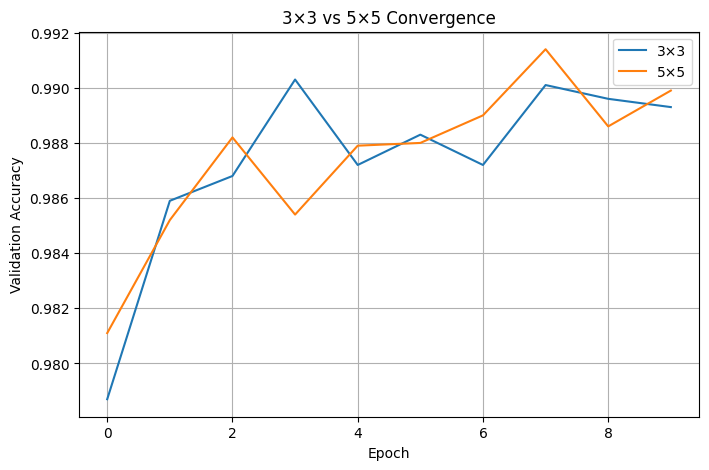

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_3x3["val_acc"],
    label="3×3"
)

plt.plot(
    history_5x5["val_acc"],
    label="5×5"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("3×3 vs 5×5 Convergence")

plt.legend()
plt.grid(True)

plt.show()

In [38]:
class PoolingModel(nn.Module):
    def __init__(self, pool_type="max"):
        super().__init__()

        self.conv = nn.Conv2d(
            1, 16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        if pool_type == "max":
            self.pool = nn.MaxPool2d(2, 2)

        elif pool_type == "avg":
            self.pool = nn.AvgPool2d(2, 2)

        elif pool_type == "none":
            self.pool = nn.Identity()

        else:
            raise ValueError("Invalid pool type")

    def forward(self, x):
        before = self.relu(self.conv(x))
        after = self.pool(before)

        return before, after


max_model = PoolingModel("max").to(device)
avg_model = PoolingModel("avg").to(device)
none_model = PoolingModel("none").to(device)

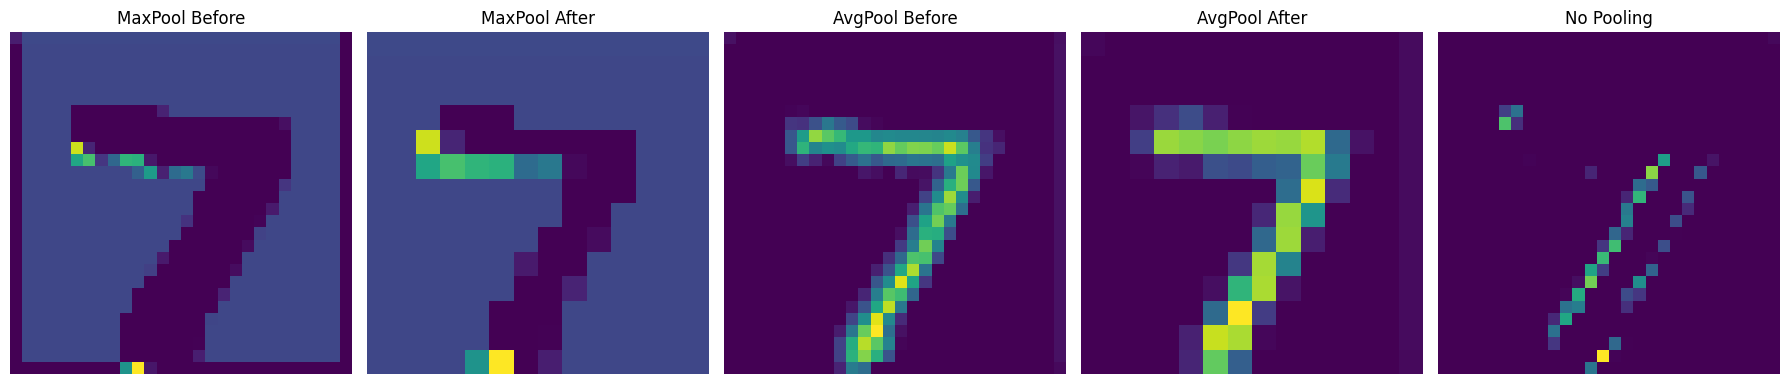

In [39]:
image, label = test_dataset[0]

image = image.unsqueeze(0).to(device)

with torch.no_grad():

    max_before, max_after = max_model(image)
    avg_before, avg_after = avg_model(image)
    none_before, none_after = none_model(image)

feature_maps = [
    ("MaxPool Before", max_before),
    ("MaxPool After", max_after),
    ("AvgPool Before", avg_before),
    ("AvgPool After", avg_after),
    ("No Pooling", none_after)
]

fig, axes = plt.subplots(
    1,
    len(feature_maps),
    figsize=(18, 4)
)

for ax, (title, fmap) in zip(axes, feature_maps):

    ax.imshow(
        fmap[0, 0].cpu(),
        cmap="viridis"
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [40]:
print("Original feature map:", max_before.shape)
print("MaxPool feature map:", max_after.shape)
print("AveragePool feature map:", avg_after.shape)
print("No pooling feature map:", none_after.shape)

Original feature map: torch.Size([1, 16, 28, 28])
MaxPool feature map: torch.Size([1, 16, 14, 14])
AveragePool feature map: torch.Size([1, 16, 14, 14])
No pooling feature map: torch.Size([1, 16, 28, 28])


In [41]:
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()

        self.conv1 = model.conv1
        self.relu1 = model.relu1
        self.pool1 = model.pool1

        self.conv2 = model.conv2
        self.relu2 = model.relu2
        self.pool2 = model.pool2

    def forward(self, x):

        f1 = self.relu1(
            self.conv1(x)
        )

        x = self.pool1(f1)

        f2 = self.relu2(
            self.conv2(x)
        )

        return f1, f2


feature_extractor = FeatureExtractor(
    model
).to(device)

feature_extractor.eval()

FeatureExtractor(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

Label: 7
Image shape: torch.Size([1, 1, 28, 28])


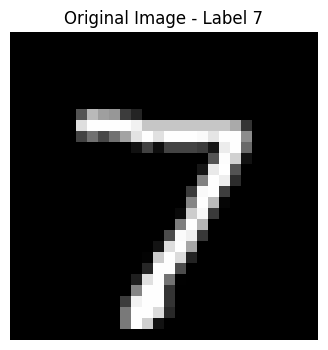

In [42]:
image, label = test_dataset[0]

original = image.unsqueeze(0).to(device)

print("Label:", label)
print("Image shape:", original.shape)

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Original Image - Label {label}")
plt.axis("off")
plt.show()

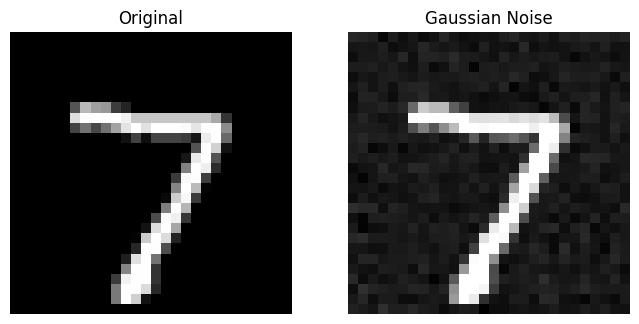

In [43]:
noise_std = 0.10

torch.manual_seed(SEED)

noise = torch.randn_like(original) * noise_std

perturbed = original + noise

perturbed = torch.clamp(
    perturbed,
    -2.5,
    2.5
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original[0, 0].cpu(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(perturbed[0, 0].cpu(), cmap="gray")
plt.title("Gaussian Noise")
plt.axis("off")

plt.show()

In [44]:
with torch.no_grad():

    original_f1, original_f2 = feature_extractor(
        original
    )

    perturbed_f1, perturbed_f2 = feature_extractor(
        perturbed
    )

print("First convolution feature maps:")
print(original_f1.shape)

print("\nSecond convolution feature maps:")
print(original_f2.shape)

First convolution feature maps:
torch.Size([1, 32, 28, 28])

Second convolution feature maps:
torch.Size([1, 64, 14, 14])


In [45]:
def normalized_l2(a, b):

    numerator = torch.norm(a - b)

    denominator = torch.norm(a) + 1e-8

    return (numerator / denominator).item()


difference_f1 = normalized_l2(
    original_f1,
    perturbed_f1
)

difference_f2 = normalized_l2(
    original_f2,
    perturbed_f2
)

print("Normalized L2 difference - Block 1:", difference_f1)
print("Normalized L2 difference - Block 2:", difference_f2)

Normalized L2 difference - Block 1: 0.13444823026657104
Normalized L2 difference - Block 2: 0.12025588005781174


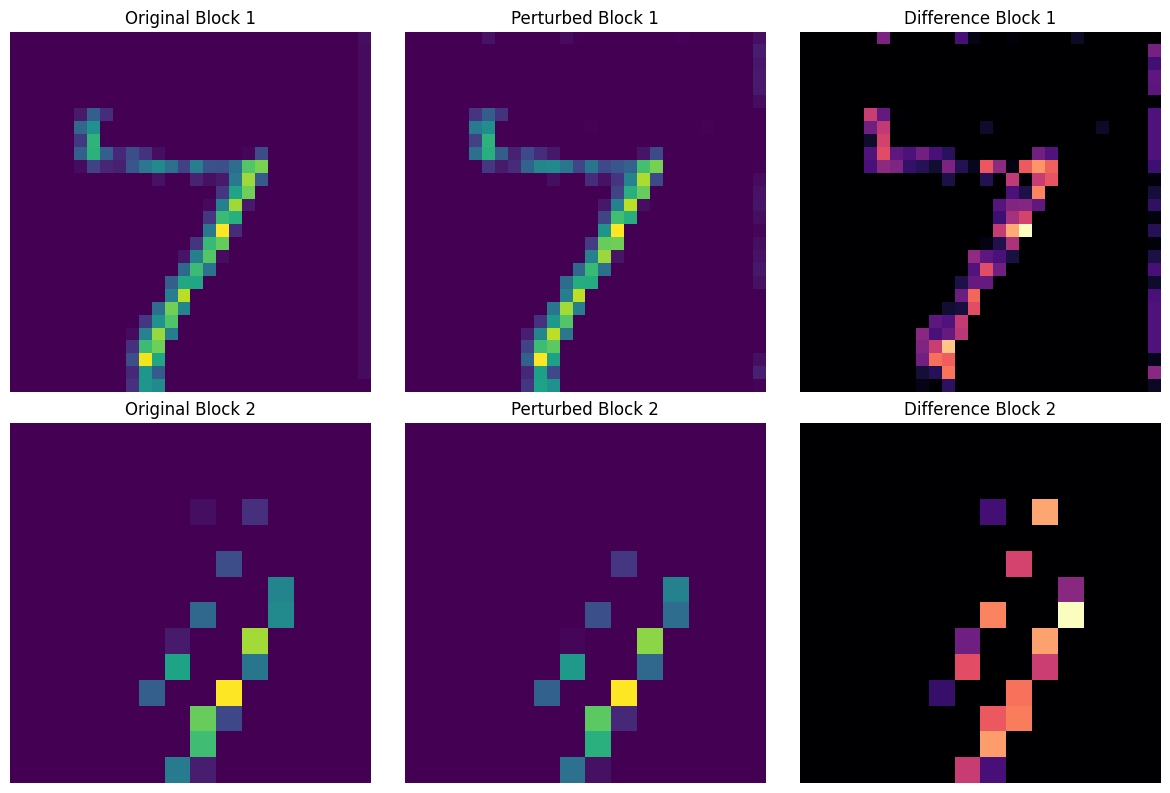

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(
    original_f1[0, 0].cpu(),
    cmap="viridis"
)
axes[0, 0].set_title("Original Block 1")

axes[0, 1].imshow(
    perturbed_f1[0, 0].cpu(),
    cmap="viridis"
)
axes[0, 1].set_title("Perturbed Block 1")

axes[0, 2].imshow(
    (original_f1[0, 0] - perturbed_f1[0, 0]).abs().cpu(),
    cmap="magma"
)
axes[0, 2].set_title("Difference Block 1")

axes[1, 0].imshow(
    original_f2[0, 0].cpu(),
    cmap="viridis"
)
axes[1, 0].set_title("Original Block 2")

axes[1, 1].imshow(
    perturbed_f2[0, 0].cpu(),
    cmap="viridis"
)
axes[1, 1].set_title("Perturbed Block 2")

axes[1, 2].imshow(
    (original_f2[0, 0] - perturbed_f2[0, 0]).abs().cpu(),
    cmap="magma"
)
axes[1, 2].set_title("Difference Block 2")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [47]:
def translate_image(image, dx, dy):

    translated = torch.zeros_like(image)

    _, _, H, W = image.shape

    source_x_start = max(0, -dx)
    source_x_end = min(W, W - dx)

    source_y_start = max(0, -dy)
    source_y_end = min(H, H - dy)

    target_x_start = max(0, dx)
    target_x_end = min(W, W + dx)

    target_y_start = max(0, dy)
    target_y_end = min(H, H + dy)

    translated[
        :,
        :,
        target_y_start:target_y_end,
        target_x_start:target_x_end
    ] = image[
        :,
        :,
        source_y_start:source_y_end,
        source_x_start:source_x_end
    ]

    return translated

In [48]:
model.eval()

translations = [
    (0, 0),
    (2, 0),
    (-2, 0),
    (0, 2),
    (0, -2),
    (3, 3)
]

translation_results = []

with torch.no_grad():

    original_output = model(original)

    original_prob = torch.softmax(
        original_output,
        dim=1
    )

    original_pred = original_prob.argmax(dim=1).item()

    original_confidence = original_prob.max().item()

    original_features = feature_extractor(
        original
    )[1]

    for dx, dy in translations:

        translated = translate_image(
            original,
            dx,
            dy
        )

        output = model(translated)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = probabilities.argmax(
            dim=1
        ).item()

        confidence = probabilities.max().item()

        features = feature_extractor(
            translated
        )[1]

        feature_difference = normalized_l2(
            original_features,
            features
        )

        translation_results.append({
            "dx": dx,
            "dy": dy,
            "prediction": prediction,
            "confidence": confidence,
            "confidence_change": confidence - original_confidence,
            "feature_difference": feature_difference
        })

translation_df = pd.DataFrame(
    translation_results
)

translation_df

,dx,dy,prediction,confidence,confidence_change,feature_difference
0,0,0,7,1.000000,0.000000e+00,0.000000
1,2,0,7,1.000000,0.000000e+00,0.936773
2,-2,0,7,1.000000,0.000000e+00,0.935229
3,0,2,7,1.000000,0.000000e+00,1.175436
4,0,-2,7,1.000000,-1.192093e-07,1.209230
5,3,3,7,0.999996,-3.576279e-06,1.369225


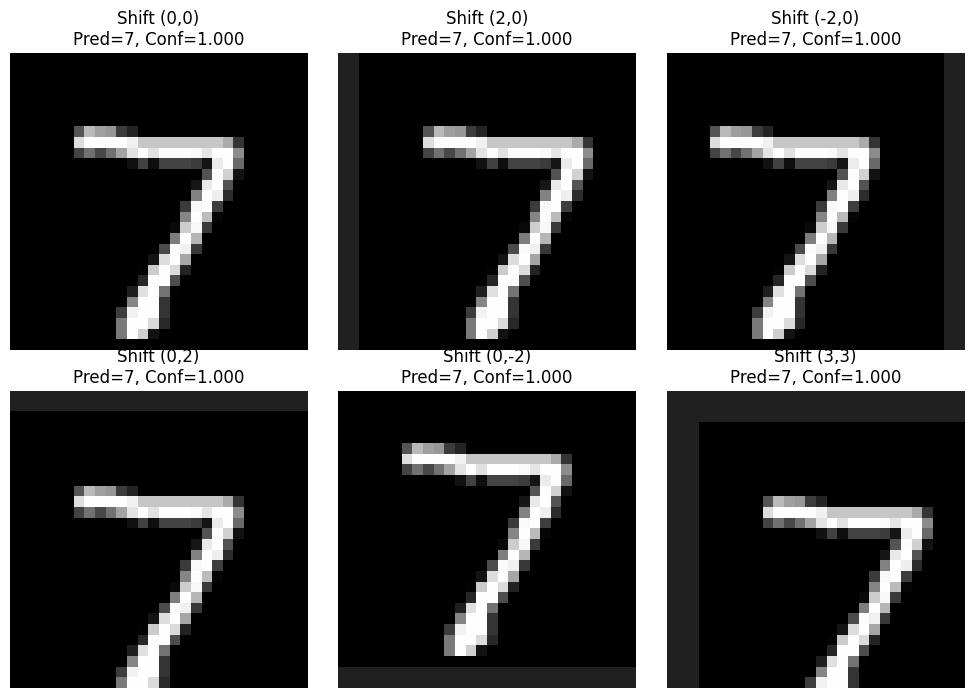

In [49]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for ax, (dx, dy) in zip(
    axes.flat,
    translations
):

    translated = translate_image(
        original,
        dx,
        dy
    )

    with torch.no_grad():

        output = model(translated)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = probabilities.argmax(
            dim=1
        ).item()

        confidence = probabilities.max().item()

    ax.imshow(
        translated[0, 0].cpu(),
        cmap="gray"
    )

    ax.set_title(
        f"Shift ({dx},{dy})\n"
        f"Pred={prediction}, Conf={confidence:.3f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()